In [66]:
import pandas as pd

In [67]:
df=pd.read_csv(r"C:\Users\ishit\OneDrive\Desktop\ML-CHURN-PROJECT\Churn_prediction\customer_churn_data.csv")

In [68]:
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB


In [70]:
df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
InternetService    297
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

In [71]:
df["InternetService"]=df["InternetService"].fillna("")

In [72]:
df.isnull().sum()

CustomerID         0
Age                0
Gender             0
Tenure             0
MonthlyCharges     0
ContractType       0
InternetService    0
TotalCharges       0
TechSupport        0
Churn              0
dtype: int64

In [73]:
df.duplicated().sum()

np.int64(0)

In [74]:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


In [75]:
numeric_columns_data=df.select_dtypes(include=["number"])

In [76]:
numeric_columns_data.corr()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
CustomerID,1.000000,0.036730,-0.018585,-0.030504,-0.027490
Age,0.036730,1.000000,0.000472,0.006362,-0.001896
Tenure,-0.018585,0.000472,1.000000,-0.014552,0.894868
MonthlyCharges,-0.030504,0.006362,-0.014552,1.000000,0.304893
TotalCharges,-0.027490,-0.001896,0.894868,0.304893,1.000000


Business Insights
1. Tenure strongly determines TotalCharges.
2. MonthlyCharges moderately affects TotalCharges.
3. Age has little linear relationship with billing variables.
4. CustomerID is irrelevant.

In [78]:
import matplotlib.pyplot as plt

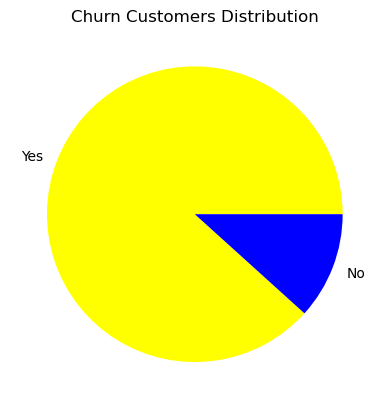

In [79]:
df["Churn"].value_counts().plot(kind="pie",colors=["yellow","blue"])
plt.title("Churn Customers Distribution")
plt.ylabel("")
plt.show()


In [80]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     62.54641
Yes    75.96077
Name: MonthlyCharges, dtype: float64

1. This suggests that customers who left were paying more on average.
2. Customers with higher monthly charges appear more likely to leave.

In [81]:
df.groupby(["Churn","Gender"])["MonthlyCharges"].mean()

Churn  Gender
No     Female    65.091912
       Male      59.013878
Yes    Female    74.975064
       Male      77.082518
Name: MonthlyCharges, dtype: float64

Customers who leave are paying significantly more on average.
Higher monthly charges appear to be associated with a greater likelihood of churn.
The company should pay special attention to customers with high monthly charges, especially:
1. Male customers paying ₹75+ per month
2. Any customer whose charges are significantly above average


In [82]:
df.groupby("Churn")["Tenure"].mean()

Churn
No     30.264957
Yes    17.476784
Name: Tenure, dtype: float64

1. Average tenure ≈ 30.26 months
2. These customers have stayed with the company for about 2.5 years on average.
3. Average tenure ≈ 17.48 months
4. These customers left after about 1.5 years on average.

This suggests:

Newer customers are more likely to leave.
Retaining customers during the first year or two is especially important.


In [83]:
df.groupby("Churn")["Age"].mean()

Churn
No     43.487179
Yes    44.831257
Name: Age, dtype: float64

This suggests that age has a very weak relationship with churn.

The difference of just 1.34 years is small, so age alone is unlikely to be a strong predictor of whether a customer will leave.

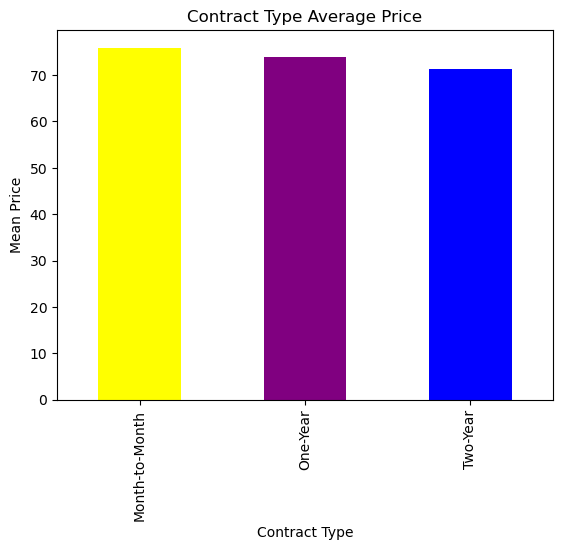

In [84]:
df.groupby("ContractType")["MonthlyCharges"].mean().plot(kind="bar",color=["yellow","purple","blue"])
plt.title("Contract Type Average Price")
plt.xlabel("Contract Type")
plt.ylabel("Mean Price")
plt.show()


1. Customers paying higher monthly charges and having no long-term      commitment   are more likely to leave.
Thus, Month-to-Month customers are often the highest-risk group.
2. This suggests that customers who commit to longer contracts receive better pricing or discounts.

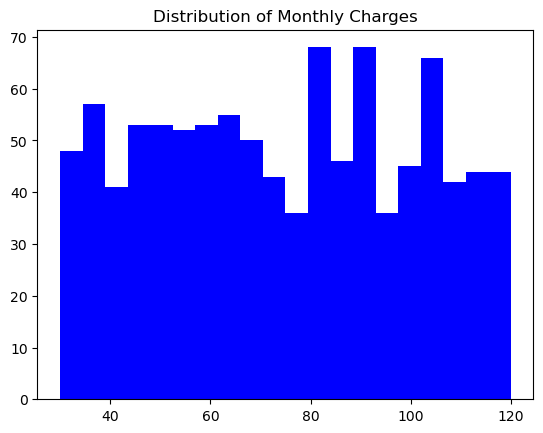

In [85]:
plt.hist(df["MonthlyCharges"],bins=20,color="blue")
plt.title("Distribution of Monthly Charges")
plt.show()

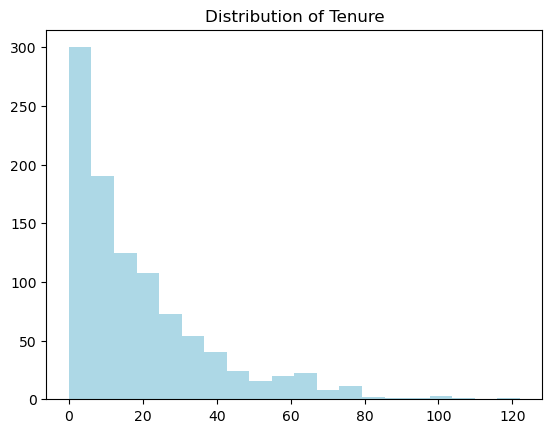

In [86]:
plt.hist(df["Tenure"],bins=20,color="lightblue")
plt.title("Distribution of Tenure")
plt.show()

In [87]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges',
       'ContractType', 'InternetService', 'TotalCharges', 'TechSupport',
       'Churn'],
      dtype='object')

In [107]:
y=df[["Churn"]]
X=df[["Age","Gender","Tenure","MonthlyCharges"]]


In [108]:
X

,Age,Gender,Tenure,MonthlyCharges
0,49,Male,4,88.35
1,43,Male,0,36.67
2,51,Female,2,63.79
3,60,Female,8,102.34
4,42,Male,32,69.01
...,...,...,...,...
995,42,Male,41,37.14
996,62,Male,9,80.93
997,51,Female,15,111.72
998,39,Male,68,65.67


Encoding Gender Column-
1 Female
0 Male

In [109]:
X["Gender"]=X["Gender"].apply(lambda x:1 if x=="Female" else 0)

C:\Users\ishit\AppData\Local\Temp\ipykernel_8728\59549676.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Gender"]=X["Gender"].apply(lambda x:1 if x=="Female" else 0)


In [110]:
type(X["Gender"][0])

numpy.int64

In [113]:
y

,Churn
0,1
1,1
2,1
3,1
4,1
...,...
995,1
996,1
997,1
998,1


Encoding Churn Column-
1 Yes
0 No

In [112]:
y["Churn"]=y["Churn"].apply(lambda x:1 if x=="Yes" else 0)

C:\Users\ishit\AppData\Local\Temp\ipykernel_8728\248740190.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y["Churn"]=y["Churn"].apply(lambda x:1 if x=="Yes" else 0)


In [114]:
type(y["Churn"][0])

numpy.int64

In [115]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2)

In [116]:
from sklearn.preprocessing import StandardScaler

In [117]:
scaler=StandardScaler()

In [118]:
X_train=scaler.fit_transform(X_train)

In [121]:
import joblib
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [128]:
X_test=scaler.transform(X_test)

In [133]:
from sklearn.metrics import accuracy_score
def modelPerformance(predications):
    print("Accuracy score on model is {:.2f}".format(accuracy_score(y_test,predications)))

In [134]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

In [136]:
logistic_model=LogisticRegression()

In [138]:
import warnings
warnings.filterwarnings("ignore")

In [139]:
logistic_model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [140]:
X

,Age,Gender,Tenure,MonthlyCharges
0,49,0,4,88.35
1,43,0,0,36.67
2,51,1,2,63.79
3,60,1,8,102.34
4,42,0,32,69.01
...,...,...,...,...
995,42,0,41,37.14
996,62,0,9,80.93
997,51,1,15,111.72
998,39,0,68,65.67


In [149]:
y_pred=logistic_model.predict(X_test)

In [150]:
modelPerformance(y_pred)

Accuracy score on model is 0.90


In [151]:
from sklearn.neighbors import KNeighborsClassifier

In [152]:
parameter_grid={
    "n_neighbors":[3, 5, 7, 9],
    "weights":["uniform","distance"]
}

In [153]:
grid_kn=GridSearchCV(KNeighborsClassifier(),parameter_grid,cv=5)

In [154]:
grid_kn.fit(X_train,y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,5


In [155]:
grid_kn.best_params_

{'n_neighbors': 5, 'weights': 'uniform'}

In [156]:
y_pred=grid_kn.predict(X_test)

In [157]:
modelPerformance(y_pred)

Accuracy score on model is 0.88


In [158]:
from sklearn.svm import SVC

In [159]:
svm=SVC()

In [160]:
parameter_grid={
    "C":[0.01,0.1,0.5,1],
    "kernel":["linear","rbf","poly"]  
}

In [161]:
gridSvc=GridSearchCV(svm,parameter_grid,cv=5)

In [162]:
gridSvc.fit(X_train,y_train)

,estimator,SVC()
,param_grid,"{'C': [0.01, 0.1, ...], 'kernel': ['linear', 'rbf', ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,0.01


In [163]:
gridSvc.best_params_

{'C': 0.01, 'kernel': 'linear'}

In [164]:
y_pred=gridSvc.predict(X_test)

In [165]:
modelPerformance(y_pred)

Accuracy score on model is 0.90


In [166]:
from sklearn.tree import DecisionTreeClassifier

In [167]:
parameter_grid={
    "criterion": ["gini","entropy"],
    "max_depth":[None,10,20,30],
    "splitter":["best","random"],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

In [168]:
grid_tree=GridSearchCV(DecisionTreeClassifier(),parameter_grid,cv=5)

In [172]:
grid_tree.fit(X_train,y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [173]:
grid_tree.best_params_

{'criterion': 'entropy',
 'max_depth': None,
 'min_samples_leaf': 4,
 'min_samples_split': 10,
 'splitter': 'random'}

In [174]:
y_pred=grid_tree.predict(X_test)

In [175]:
modelPerformance(y_pred)

Accuracy score on model is 0.86


In [176]:
from sklearn.ensemble import RandomForestClassifier

In [177]:
rfc_model=RandomForestClassifier()

In [178]:
parameter_grid={
    "n_estimators":[32,64,128,256],
    "max_features":[2,3,4],
    "bootstrap":[True,False]
}

In [180]:
grid_rfc=GridSearchCV(rfc_model,parameter_grid,cv=5)

In [181]:
grid_rfc.fit(X_train,y_train)

,estimator,RandomForestClassifier()
,param_grid,"{'bootstrap': [True, False], 'max_features': [2, 3, ...], 'n_estimators': [32, 64, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,256


In [182]:
grid_rfc.best_params_

{'bootstrap': True, 'max_features': 3, 'n_estimators': 256}

In [184]:
y_pred=grid_rfc.predict(X_test)

In [185]:
modelPerformance(y_pred)

Accuracy score on model is 0.88


In [187]:
best_model=gridSvc.best_estimator_

In [188]:
joblib.dump(best_model,"model.pkl")

['model.pkl']